In [ ]:
import pandas as pd
import numpy as np

data_df = pd.read_csv("https://www.statlearning.com/s/Advertising.csv", index_col = 0)
data_df.head()

,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


In [ ]:
X = data_df.drop("sales", axis = 1).to_numpy()
y = data_df[["sales"]].to_numpy()

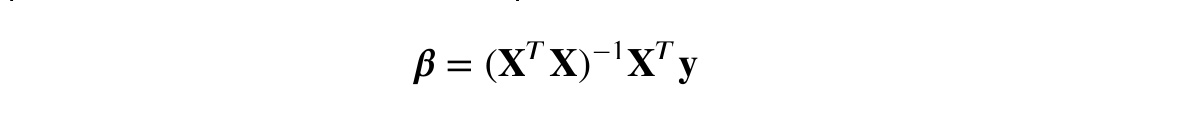

In [ ]:
X = np.concat(
    ( np.ones((X.shape[0], 1)), X ),
    axis = 1
)

In [ ]:
X.shape

(200, 4)

In [ ]:
betas = np.linalg.inv(np.dot(X.T, X)).dot(X.T).dot(y)

In [ ]:
betas = betas.flatten()
print(betas)

[ 2.93888937e+00  4.57646455e-02  1.88530017e-01 -1.03749304e-03]


In [ ]:
print(f"y = {betas[0]:.3f} + {betas[1]:.3f} x1 + {betas[2]:.3f} x2 + ({betas[3]:.3f}) x3")

y = 2.939 + 0.046 x1 + 0.189 x2 + (-0.001) x3


# SKlearn Implementation

In [ ]:
random_state = 987

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import max_error, mean_absolute_error, mean_squared_error, r2_score

In [ ]:
X = data_df.drop("sales", axis = 1).to_numpy()
y = data_df[["sales"]].to_numpy()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=987)

In [ ]:
linear_regression = LinearRegression()
linear_regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 3)","[[ 0.05, 0.19,-0. ]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[2.87]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[1079.57, 277.13, 170.48]"


In [ ]:
# Beta0
linear_regression.intercept_

array([2.8746144])

In [ ]:
# Betas
linear_regression.coef_

array([[ 0.04606898,  0.18712568, -0.00054721]])

In [ ]:
SSE = np.sum(np.power(y_train - linear_regression.predict(X_train), 2))
SSE

np.float64(450.86255697798015)

In [ ]:
y_pred = linear_regression.predict(X_test)

In [ ]:
max_error(y_test, y_pred)

4.239320518515523

In [ ]:
mean_absolute_error(y_test, y_pred)

1.3345278468817416

In [ ]:
mean_squared_error(y_test, y_pred)

2.661194761189464

In [ ]:
r2_score(y_test, y_pred)

0.9018693692889659

In [ ]:
n,d = X_train.shape
r2_coeff = r2_score(y_test, y_pred)

In [ ]:
adj_r2 = 1 - (1 - r2_coeff) * ((n-1) / (n-d-1))
adj_r2

0.8999822417752922

*Scenario:* A real estate analyst models home prices using square footage ($X_1$) and number of rooms ($X_2$). Adding $X_2$ causes the standard error of $X_1$'s coefficient to quadruple, though overall $R^2$ remains high at 0.82.

**Q2. Which statistical issue is occurring in this model?**

* A) Heteroscedasticity, which biases the point estimates of the coefficients.
* B) Multicollinearity, which inflates coefficient variance and makes individual estimates unstable.
* C) Autocorrelation, which artificially inflates the overall model $R^2$.
* D) Underfitting, which causes severe non-linearity in the model residuals.

### Adjusted R2 Cofficient

R-squared is a goodness-of-fit measure for linear regression models. 

R-squared represents the proportion of the variance in the dependent variable that is predictable from the independent variables. It ranges from 0 to 1, where 1 indicates a perfect fit. It is calculated as:

$R^2 = 1 - \frac{RSS}{TSS}$

Where RSS is the residual sum of squares and TSS is the total sum of squares.

The RSS (Residual Sum of Squares) represents the sum of squared differences between the observed dependent variable values (y) and the predicted values (ŷ) obtained from the linear regression model. Mathematically, it is calculated as follows:

$RSS = Σ(y - ŷ)^2$

On the other hand, the TSS (Total Sum of Squares) represents the total variation in the dependent variable (y) from its mean (ȳ). It measures the sum of squared differences between each observed dependent variable value (y) and the mean of the dependent variable (ȳ). Mathematically, it is calculated as follows:

$TSS = Σ(y - ȳ)^2$

R-squared is always between 0 and 100%:

* 0% represents a model that does not explain any of the variation in the response variable around its mean. The mean of the dependent variable predicts the dependent variable as well as the regression model.
* 100% represents a model that explains all the variation in the response variable around its mean.

### The Main Idea Behind Adjusted R²

Adjusted R² asks an important question:

> "Did the new variable improve the model enough to justify its complexity?"

Instead of blindly rewarding additional variables, it introduces a penalty.

Regular R² only rewards:

* Better fit

Adjusted R² balances two things:

| Goal            | Effect  |
| --------------- | ------- |
| Better fit      | Reward  |
| More predictors | Penalty |

So:

* Useful variables → Adjusted R² increases
* Useless variables → Adjusted R² decreases


Adjusted R² modifies R² by penalizing unnecessary predictors.

It increases only if:

> The new variable improves the model more than expected by chance.


## Formula

$Adjusted\ R^2 = 1 - (1 - R^2)\frac{n-1}{n-p-1} $

Where:

| Symbol | Meaning                |
| ------ | ---------------------- |
| (R^2)  | Regular R²             |
| (n)    | Number of observations |
| (p)    | Number of predictors   |



### Core Idea

Adjusted R² introduces a penalty factor:

$ \frac{n-1}{n-p-1} $

As the number of predictors (p) increases:

* Denominator becomes smaller
* Penalty becomes larger

Therefore:

* Irrelevant variables may reduce Adjusted R².
* Useful variables increase Adjusted R².


# 7. Interpretation

| Situation             | Interpretation            |
| --------------------- | ------------------------- |
| Adjusted R² increases | New feature is useful     |
| Adjusted R² decreases | New feature is not useful |
| Adjusted R² unchanged | Little contribution       |